In [1]:
#Dummy dataset (T15 x CMJ)

In [2]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error

In [17]:
#Load and inspect
df = pd.read_csv("Dummy T15 x CMJ.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nEvent names:", df[EVENT_COL].unique())
print("\nSample:\n", df.head())

Shape: (400, 7)
Columns: ['RaceId', 'PoolLength', 'RaceEventName', 'AthleteGenderName', 'Lap1_15mElapsedTime', 'Jump Height (Flight Time) [cm]', 'Peak Power / BM [W/kg]']

Event names: <StringArray>
[   '50 m Backstroke',  '50 m Breaststroke',     '50 m Butterfly',
     '50 m Freestyle',   '100 m Backstroke', '100 m Breaststroke',
    '100 m Butterfly',    '100 m Freestyle']
Length: 8, dtype: str

Sample:
                                  RaceId  PoolLength    RaceEventName  \
0  0118aae9-93b1-40e7-86af-df7db6444c9d          50  50 m Backstroke   
1  028b04a7-0f82-45b6-a295-325027f665e1          50  50 m Backstroke   
2  0465b974-eb8a-40a0-97d1-01028f1130e5          50  50 m Backstroke   
3  04ed6359-e0a1-4fcf-9bc2-fb396ac186e9          50  50 m Backstroke   
4  05bd7804-19d7-45a2-b151-59639351e959          50  50 m Backstroke   

  AthleteGenderName  Lap1_15mElapsedTime  Jump Height (Flight Time) [cm]  \
0               Men                 6.04                          44.648   
1    

In [18]:
#Constants

EVENT_COL      = "RaceEventName"
T15_COL        = "Lap1_15mElapsedTime"
CMJ_COL        = "Jump Height (Flight Time) [cm]"

DISTANCES      = [50, 100]
STROKES        = ["Freestyle", "Backstroke", "Breaststroke", "Butterfly"]
MIN_N          = 3  #minimum rows needed for model

STROKE_COLORS = {
    "Freestyle":    "#2E86AB",
    "Backstroke":   "#E84855",
    "Breaststroke": "#F4A261",
    "Butterfly":    "#57CC99",
}

In [12]:
#Parse distance from event name 
#Extract distance from the event name e.g. "50 m Freestyle" -> 50

df["distance"] = df[EVENT_COL].str.extract(r"(\d+)").astype(int)
df = df[df["distance"].isin(DISTANCES)]

print("Rows after distance filter:", len(df))
print("Distances found:", df["distance"].unique())

Rows after distance filter: 400
Distances found: [ 50 100]


In [13]:
#OLS + Neural Network with LOOCV 

def run_models_loocv(X, y, label=""):
    X = np.array(X).reshape(-1, 1)
    y = np.array(y)
    loo = LeaveOneOut()

    # OLS
    ols_preds = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        m = LinearRegression()
        m.fit(X[train_idx], y[train_idx])
        ols_preds[test_idx] = m.predict(X[test_idx])

    ols_r2   = r2_score(y, ols_preds)
    ols_rmse = np.sqrt(mean_squared_error(y, ols_preds))
    ols_full = LinearRegression().fit(X, y)

    # Neural network
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    nn_preds = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X_scaled):
        nn = MLPRegressor(
            hidden_layer_sizes=(16, 8),
            activation="relu",
            max_iter=5000,
            random_state=42
        )
        nn.fit(X_scaled[train_idx], y[train_idx])
        nn_preds[test_idx] = nn.predict(X_scaled[test_idx])

    nn_r2   = r2_score(y, nn_preds)
    nn_rmse = np.sqrt(mean_squared_error(y, nn_preds))

    if label:
        print(f"\n--- {label} (n={len(y)}) ---")
        print(f"  OLS  — R²: {ols_r2:.3f}  RMSE: {ols_rmse:.3f}s")
        print(f"  NN   — R²: {nn_r2:.3f}  RMSE: {nn_rmse:.3f}s")

    return {
        "n": len(y), "X": X, "y": y,
        "ols_r2": ols_r2, "ols_rmse": ols_rmse, "ols_model": ols_full,
        "nn_r2":  nn_r2,  "nn_rmse":  nn_rmse,
    }

In [14]:
#Run models
results = {}

for distance in DISTANCES:
    print(f"\n{'='*50}\n  {distance}m events\n{'='*50}")
    for stroke in STROKES:
        mask = (
            (df["distance"] == distance) &
            (df[EVENT_COL].str.contains(stroke, case=False, na=False))
        )
        subset = df[mask].dropna(subset=[CMJ_COL, T15_COL])

        if len(subset) < MIN_N:
            print(f"  {stroke} — skipped (n={len(subset)})")
            continue

        res = run_models_loocv(subset[CMJ_COL], subset[T15_COL], f"{distance}m {stroke}")
        results[(distance, stroke)] = res


  50m events

--- 50m Freestyle (n=50) ---
  OLS  — R²: 0.973  RMSE: 0.096s
  NN   — R²: 0.644  RMSE: 0.350s

--- 50m Backstroke (n=50) ---
  OLS  — R²: 0.944  RMSE: 0.146s
  NN   — R²: 0.577  RMSE: 0.403s

--- 50m Breaststroke (n=50) ---
  OLS  — R²: 0.798  RMSE: 0.234s
  NN   — R²: 0.371  RMSE: 0.413s

--- 50m Butterfly (n=50) ---
  OLS  — R²: 0.277  RMSE: 0.403s
  NN   — R²: 0.112  RMSE: 0.447s

  100m events

--- 100m Freestyle (n=50) ---
  OLS  — R²: 0.872  RMSE: 0.169s
  NN   — R²: 0.617  RMSE: 0.291s

--- 100m Backstroke (n=50) ---
  OLS  — R²: 0.947  RMSE: 0.138s
  NN   — R²: 0.671  RMSE: 0.346s

--- 100m Breaststroke (n=50) ---
  OLS  — R²: 0.984  RMSE: 0.059s
  NN   — R²: 0.734  RMSE: 0.240s

--- 100m Butterfly (n=50) ---
  OLS  — R²: 0.214  RMSE: 0.426s
  NN   — R²: -0.076  RMSE: 0.498s


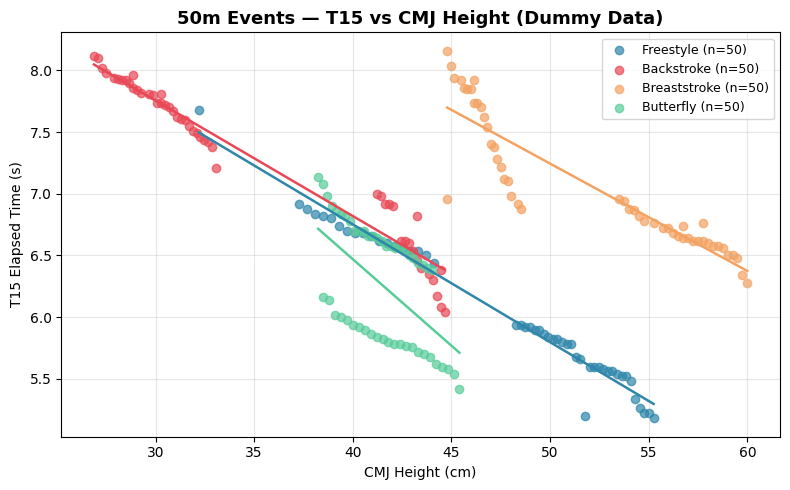

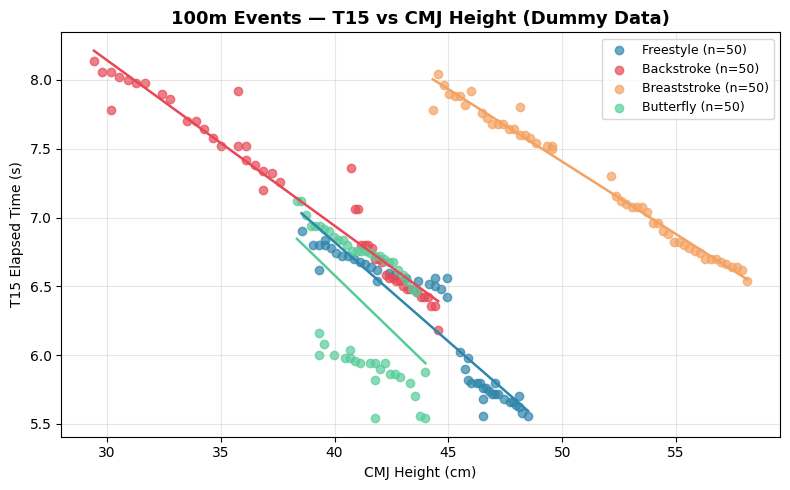

In [15]:
#Plot
for distance in DISTANCES:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f"{distance}m Events — T15 vs CMJ Height (Dummy Data)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("CMJ Height (cm)")
    ax.set_ylabel("T15 Elapsed Time (s)")

    for stroke in STROKES:
        key = (distance, stroke)
        if key not in results:
            continue
        res = results[key]
        X, y = res["X"].flatten(), res["y"]
        color = STROKE_COLORS[stroke]

        ax.scatter(X, y, color=color, alpha=0.7,
                   label=f"{stroke} (n={res['n']})")
        x_line = np.linspace(X.min(), X.max(), 100)
        y_line = res["ols_model"].predict(x_line.reshape(-1, 1))
        ax.plot(x_line, y_line, color=color, linewidth=1.8)

    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"dummy_T15_CMJ_{distance}m.png", dpi=150)
    plt.show()

In [16]:
#Summary table

rows = []
for (distance, stroke), res in results.items():
    rows.append({
        "Distance":  f"{distance}m",
        "Stroke":    stroke,
        "n":         res["n"],
        "OLS R²":    round(res["ols_r2"],  3),
        "OLS RMSE":  round(res["ols_rmse"], 3),
        "NN R²":     round(res["nn_r2"],   3),
        "NN RMSE":   round(res["nn_rmse"],  3),
    })

summary = pd.DataFrame(rows).sort_values(["Distance", "Stroke"])
print(summary.to_string(index=False))

Distance       Stroke  n  OLS R²  OLS RMSE  NN R²  NN RMSE
    100m   Backstroke 50   0.947     0.138  0.671    0.346
    100m Breaststroke 50   0.984     0.059  0.734    0.240
    100m    Butterfly 50   0.214     0.426 -0.076    0.498
    100m    Freestyle 50   0.872     0.169  0.617    0.291
     50m   Backstroke 50   0.944     0.146  0.577    0.403
     50m Breaststroke 50   0.798     0.234  0.371    0.413
     50m    Butterfly 50   0.277     0.403  0.112    0.447
     50m    Freestyle 50   0.973     0.096  0.644    0.350
